# PROC MODECLUS를 이용한 전력망 감시소 밀도 기반 군집분석

## 요약

한 배전(配電) 유틸리티 회사가 PROC MODECLUS를 사용해 전력망 감시소
(변전소와 피더 센서)의 지도 좌표만으로 비모수적 밀도 기반 군집을
찾는다. MODECLUS는 부지들에 대한 밀도 표면을 추정하고, 저밀도
간격으로 구분되는 고밀도 영역을 군집으로 간주한다. 시뮬레이션한
부지 90곳에 균일커널 반경 3km를 적용하면, 데이터에 내장해 둔 세
개의 밀집 서비스 구역이 가장 큰 세 군집(24, 24, 21개 부지)으로
복원되고, 흩어진 농촌 부지들은 희박한 영역에 위치하여 한두 곳씩의
소규모 군집으로 갈라져 나온다. 이 고립 부지 목록이 바로 실무
산출물이다 - 자본계획팀을 위한 원격 자산 후보 목록이다.

## 데이터 출처

| 데이터셋 | 행 수 | 설명 |
|---------|------|-------------|
| `grid_sites` | 90 | `call streaminit(70531)`과 `rand()`로 인라인 생성한 합성 배전 감시소 데이터. 서로 다른 지도 중심점 주변의 이변량 정규분포에서 뽑은 세 개의 밀집 서비스 구역(도심, 교외, 산업단지)과, 관할구역 전체에 균등하게 뽑은 22곳의 흩어진 농촌 부지로 구성된다. |

| 변수 | 유형 | 설명 |
|----------|------|-------------|
| `site_id` | 숫자 | 고유 감시소 식별자(1~90). |
| `region` | 문자 | 각 부지가 어떻게 생성되었는지 기록하는 기획용 라벨(도심, 교외, 산업단지, 농촌); 군집분석에서는 제외한다. |
| `x_km`, `y_km` | 숫자 | 유틸리티 기획 격자 위의 부지 위치(km); 군집분석에 사용하는 변수다. |
| `peak_load_mw` | 숫자 | 부지에서 관측된 연간 최대부하(MW); 후속 해석을 위해 함께 싣는다. |

# 전력망 감시소의 밀도 기반 군집분석

한 지역 배전 유틸리티 회사가 관할구역 전체에 퍼진 **감시소**
(변전소와 피더 센서) 네트워크를 운영한다. 기획팀은 그룹 수를
미리 정하지 않고 순전히 지리적 위치만으로 이 부지들을 자연스러운
**서비스 밀집구역**으로 묶고, 어느 밀집구역에도 속하지 않는
**고립된 농촌 자산**을 식별하고자 한다.

`PROC MODECLUS`는 이 작업에 잘 맞는다: *비모수적 밀도 기반* 군집분석을
수행하기 때문이다. 부지들에 대한 밀도함수를 추정한 다음, 저밀도
간격으로 구분되는 고밀도 부지 영역을 군집으로 간주한다. 희박한
이상치는 하나의 밀집구역에 흡수되기보다 자신만의 작은 군집으로
남는다 - 원격 부지를 표시하려는 우리 목적에 정확히 부합하는
동작이다.

이 노트북은 다음을 수행한다:
1. 부지 90곳으로 이루어진 현실적인 합성 부지 네트워크를 생성한다.
2. **균일커널**로 부지 밀도를 추정하고, 복원된 밀집구역이 안정적인지
   확인하기 위해 평활 반경 `R=`을 스캔한다.
3. 작업 반경을 고정한 뒤 각 부지의 밀도와 군집 라벨을 담은 `OUT=`
   데이터셋을 작성하고 결과를 지도에 표시한다.

## 1단계 -- 합성 감시소 네트워크 생성

부지 90곳을 시뮬레이션한다. 세 개의 밀집 **서비스 구역**을 서로 다른
지도 중심점 주변의 이변량 정규분포에서 뽑는다(도심은 (12, 30) 부근,
교외는 (30, 15) 부근, 산업단지는 (20, 42) 부근), 각각 24, 24, 20곳의
조밀한 고밀도 덩어리를 이룬다. 네 번째로 22곳의 **농촌** 부지를
관할구역 전체에 균등하게 뽑아, 유틸리티가 고립된 것으로 취급할
희박하고 흩어진 부지를 만든다.

`region` 라벨은 각 부지가 어떻게 생성되었는지 기록한다; MODECLUS가
좌표만으로 구조를 재발견하도록 이를 군집분석에서 일부러 **제외한다**.
`peak_load_mw`는 이후 해석을 위해 함께 가져간다.

In [1]:
데이터 grid_sites;
   호출 streaminit(70531);
   길이 region $ 24;

   /* 도심 밀집 서비스 구역 */
   반복 site_id = 1 까지 24;
      region = '도심';
      x_km = 12 + rand('normal') * 1.3;
      y_km = 30 + rand('normal') * 1.3;
      peak_load_mw = 4.5 + rand('normal') * 0.6;
      출력;
   종료;

   /* 교외 구역 */
   반복 site_id = 25 까지 48;
      region = '교외';
      x_km = 30 + rand('normal') * 1.6;
      y_km = 15 + rand('normal') * 1.6;
      peak_load_mw = 2.8 + rand('normal') * 0.5;
      출력;
   종료;

   /* 산업단지 구역(높은 최대부하) */
   반복 site_id = 49 까지 68;
      region = '산업단지';
      x_km = 20 + rand('normal') * 1.4;
      y_km = 42 + rand('normal') * 1.4;
      peak_load_mw = 6.1 + rand('normal') * 0.8;
      출력;
   종료;

   /* 흩어진 농촌 부지(희박, 저부하) */
   반복 site_id = 69 까지 90;
      region = '농촌';
      x_km = 2 + rand('uniform') * 46;
      y_km = 2 + rand('uniform') * 50;
      peak_load_mw = 0.8 + rand('uniform') * 1.2;
      출력;
   종료;
실행;

제목 '합성 전력망 감시소 데이터';
처리 MEANS 데이터=grid_sites n mean std MIN MAX maxdec=2;
   분류 region;
   변수 x_km y_km peak_load_mw;
   라벨 region="지역" x_km="동서좌표(km)" y_km="남북좌표(km)" peak_load_mw="최대부하(MW)";
실행;

                                                     합성 전력망 감시소 데이터                                                     

                                                  The MEANS Procedure

                                       Analysis Variable : x_km 동서좌표(km)

        지역                    N Obs           Mean        Std Dev        Minimum        Maximum
        ---------------------------------------------------------------------------------------
        교외                       24          29.96           1.73          26.51          33.60
        농촌                       22          29.79          10.62          11.06          47.45
        도심                       24          12.07           1.34           8.65          14.42
        산업단지                     20          20.36           0.96          18.52          21.53
        ---------------------------------------------------------------------------------------

                                       Analysis Variable : y


NOTE: DATA grid_sites


NOTE: Wrote grid_sites (90 rows, 5 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: Option TITLE changed to 합성 전력망 감시소 데이터.
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


평균값은 세 개의 조밀한 밀집구역과 하나의 흩어진 그룹을 확인해준다.
세 밀집 지역은 잘 분리된 중심점 주변에서 좌표 표준편차가 작고(각
축에서 대략 1~1.7km), 농촌 그룹은 격자 전체에 퍼져 있다(두 축
모두 표준편차 10km 이상). 최대부하 역시 구역들을 구분한다 -
산업단지 부지는 평균 약 6MW, 도심은 약 4.6MW, 교외는 약 2.7MW,
농촌 부지는 약 1.5MW다 - 지리적 군집을 확보한 뒤에는 이 값이
유용한 맥락이 된다.

## 2단계 -- 균일커널 밀도 군집분석과 반경 스캔

균일커널 밀도추정은 **반경 `R=`**을 사용한다: `R`킬로미터 이내의
모든 부지가 해당 부지의 국소밀도에 기여한다. `R`이 작으면 밀도가
울퉁불퉁해져 관할구역이 잘게 쪼개지고, `R`이 크면 과도하게
평활화되어 밀집구역들이 합쳐진다. 노련한 SAS 사용자는 단일 값을
신뢰하지 않는다 - 여러 반경을 스캔하며 군집 수가 **안정적**인
구간을 찾는다. 이때 밀집구역은 그대로 유지되고 흩어진 단일부지
군집의 수만 변한다.

여기서 `M=1`은 군집분석 방법 1(표준 비모수적 방법)을 선택하고,
`R=2.5 to 4 by 0.5`로 한 번에 여러 반경을 요청한다. MODECLUS는
반경마다 한 번씩 분석을 실행하고 각각의 군집 수를 보고한다.
`SHORT`는 장황한 군집별 통계 출력을 생략한다.

In [2]:
제목 '전력망 부지의 균일커널 밀도 군집분석';
title2 '반경 스캔 R = 2.5 ~ 4.0 km';

처리 MODECLUS 데이터=grid_sites m=1 r=2.5 to 4 by 0.5 short;
   변수 x_km y_km;
   id site_id;
실행;

                                                  전력망 부지의 균일커널 밀도 군집분석                                                  
                                                 반경 스캔 R = 2.5 ~ 4.0 km                                                 


                                                 The MODECLUS Procedure                                                 

  Method: 1
  Number of Observations: 90
  Number of Variables: 2
  Variables: x_km y_km

  Density Estimation: Bandwidth=2.5000
  Number of Clusters: 23

  Density Estimation: Bandwidth=3.0000
  Number of Clusters: 22

  Density Estimation: Bandwidth=3.5000
  Number of Clusters: 19

  Density Estimation: Bandwidth=4.0000
  Number of Clusters: 18





NOTE: Option TITLE changed to 전력망 부지의 균일커널 밀도 군집분석.
NOTE: Option TITLE2 changed to 반경 스캔 R = 2.5 ~ 4.0 km.
NOTE: PROC MODECLUS data=grid_sites method=1

NOTE: Using Python/scipy for density-based clustering
NOTE: Density estimation: 23 Cluster(s) found. Bandwidth=2.5000 Mode-based Clustering complete.
NOTE: Density estimation: 22 Cluster(s) found. Bandwidth=3.0000 Mode-based Clustering complete.
NOTE: Density estimation: 19 Cluster(s) found. Bandwidth=3.5000 Mode-based Clustering complete.
NOTE: Density estimation: 18 Cluster(s) found. Bandwidth=4.0000 Mode-based Clustering complete.
NOTE: PROC MODECLUS: 90 observations, 2 variables, method=1


군집 수는 스캔 전 구간에서 완만하게만 움직인다 -- `R=2.5`에서 23개,
`R=3.0`에서 22개, `R=3.5`에서 19개, `R=4.0`에서 18개다. 이 높은
원시 개수는 흩어진 농촌 부지에서 비롯된다: 각 고립 부지는 자신만의
희박한 이웃 안에 놓여 한 부지짜리 군집을 이루므로, 18~23개
"군집" 대부분은 단일부지 군집이다. 그 아래에서 변하지 않는 것이
바로 중요한 구조다 -- 세 밀집구역은 모든 반경에서 크고 잘 분리된
세 개의 군집으로 남는다. `R`이 넓어질수록 흩어진 단일부지 몇 곳이
이웃이나 인근 밀집구역과 합쳐지는데, 이것이 전체 개수가 요동치지
않고 서서히 줄어드는 이유다. 이러한 안정성이 바로 세 밀집구역
해가 실재하며 특정 대역폭의 우연한 산물이 아니라는 신호다.

## 3단계 -- 지도화를 위한 최종 군집 해

스캔 전체에서 세 밀집구역이 안정적임을 확인했으므로, 작업 반경
하나(`R=3`km)를 고정하고 전체 군집별 출력을 위한 **ALL** 옵션과,
원좌표에 `DENSITY` 추정치와 `CLUSTER` 배정을 함께 기록해 지도화할
수 있도록 **OUT=**을 요청한다. 군집은 최빈값 밀도 내림차순으로
번호가 매겨지므로, 가장 밀집한 구역이 군집 1, 2, 3이 되고 희박한
부지는 더 큰 번호를 받는다.

In [3]:
제목 '최종 밀도기반 군집 해';
title2 '균일 커널, R = 3 km';

처리 MODECLUS 데이터=grid_sites m=1 r=3 out=join_out ALL;
   변수 x_km y_km;
   id site_id;
실행;

                                                      최종 밀도기반 군집 해                                                      
                                                    균일 커널, R = 3 km                                                     


                                                 The MODECLUS Procedure                                                 

  Method: 1
  Number of Observations: 90
  Number of Variables: 2
  Variables: x_km y_km

  Density Estimation: Bandwidth=3.0000
  Number of Clusters: 22

  Cluster Summary
  ---------------------------------------------------------------
  Cluster   N   Mode   Mode Density
  ---------------------------------------------------------------
        1   24           5      0.009038
        2   24          46      0.007860
        3   21          56      0.007860
        4    3          83      0.001179
        5    1          29      0.000393
        6    1          69      0.000393
        7    1          70      0.000393
      


NOTE: Option TITLE changed to 최종 밀도기반 군집 해.
NOTE: Option TITLE2 changed to 균일 커널, R = 3 km.
NOTE: PROC MODECLUS data=grid_sites method=1

NOTE: Using Python/scipy for density-based clustering
NOTE: Density estimation: 22 Cluster(s) found. Bandwidth=3.0000 Mode-based Clustering complete.
NOTE: PROC MODECLUS: 90 observations, 2 variables, method=1


군집 요약은 구조를 명확하게 드러낸다. `R=3` 해는 **22개 군집**을
반환하지만, 밀도에 따라 뚜렷하게 층이 나뉜다:

- **군집 1** -- 24개 부지, 최빈값 밀도 약 0.0090(도심 구역).
- **군집 2** -- 24개 부지, 최빈값 밀도 약 0.0079(교외 구역).
- **군집 3** -- 21개 부지, 최빈값 밀도 약 0.0079(산업단지 구역;
  가장자리에 걸친 농촌 부지 한 곳을 함께 포함한다).
- **군집 4** -- 3개 부지, 최빈값 밀도 약 0.0012로 중간 수준이다.
- **군집 5-22** -- 각 1개 부지짜리 군집 18개, 최빈값 밀도 약
  0.0004로 밀집구역보다 약 20배 이상 희박하다.

세 밀집구역이 90개 부지 중 69개를 차지하며, 나머지 21개 부지가
흩어진 농촌 자산으로 저밀도 이웃 안에 홀로 또는 거의 홀로 놓여
있다. 서비스 밀집구역과 고립 부지를 가르는 기준은 미리 정한
군집 수가 아니라 밀도다.

## 4단계 -- 군집 지도화

각 부지를 세 밀집구역 중 하나에 속하는지(`cluster <= 3`) 아니면
희박한 소규모 군집에 속하는지로 표시한 다음, 이 상태에 따라 색을
입혀 모든 부지를 지도 좌표에 표시한다. 이는 기획자의 관점이다:
밀집구역은 서비스 구역으로 관리하고, 고립 부지는 별도 조치
대상으로 표시한다.

                                                  복원된 서비스 밀집구역과 고립 부지                                                   
                                                 균일커널 밀도 군집분석, R = 3 km                                                 




NOTE: DATA mapped


NOTE: Read 90 rows from join_out.
NOTE: Wrote mapped (90 rows, 10 columns).
NOTE: DATA elapsed:
  wall  0.01 seconds
  cpu   0.01 seconds
NOTE: Option TITLE changed to 복원된 서비스 밀집구역과 고립 부지.
NOTE: Option TITLE2 changed to 균일커널 밀도 군집분석, R = 3 km.
NOTE: PROC SGPLOT data=mapped

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


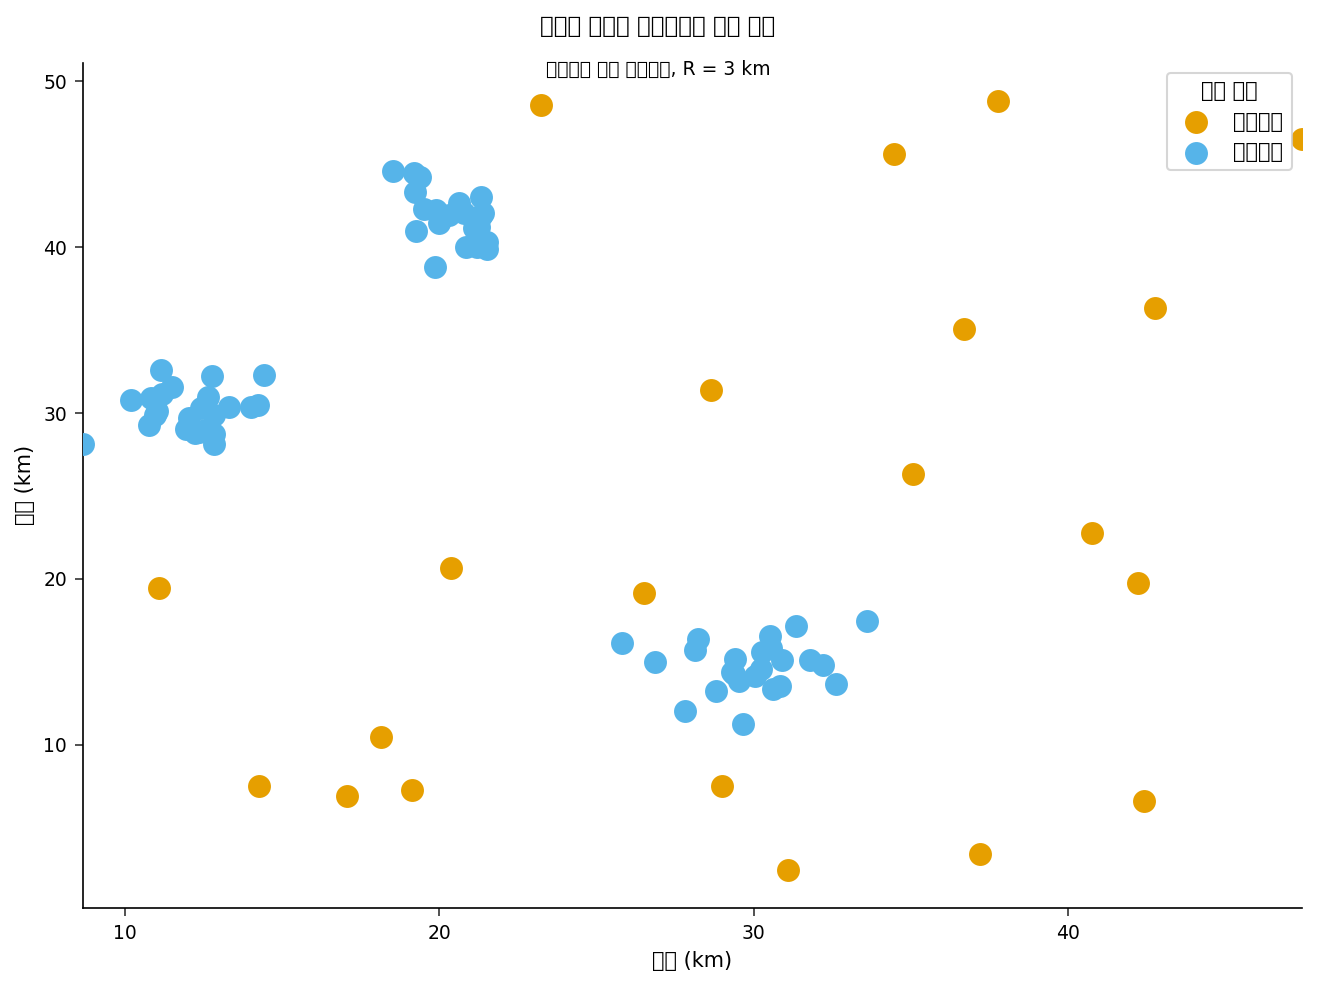

In [4]:
데이터 mapped;
   설정 join_out;
   길이 status $ 24;
   만약 CLUSTER <= 3 이면 status = '밀집구역';
   아니면 status = '고립지점';
실행;

제목 '복원된 서비스 밀집구역과 고립 부지';
title2 '균일커널 밀도 군집분석, R = 3 km';
처리 SGPLOT 데이터=mapped;
   SCATTER x=x_km y=y_km / GROUP=status markerchar=CLUSTER
                           MARKERATTRS=(size=10);
   XAXIS label='동서 (km)';
   YAXIS label='남북 (km)';
   keylegend / title='부지 상태';
실행;

제목;

## 결과 해석

**MODECLUS가 찾아낸 것.** `(x_km, y_km)`만으로 이 절차는 데이터에
내장해 둔 세 개의 밀집 서비스 구역 -- 도심, 교외, 산업단지 덩어리 --
을 가장 크고 밀도가 높은 세 군집(24, 24, 21개 부지)으로 복원한다.
관할구역 전체에 균등하게 뽑은 흩어진 농촌 부지들은 희박한 영역에
위치하여, 하나의 밀집구역에 흡수되기보다 자신만의 한두 부지짜리
군집으로 갈라져 나온다. 지도 위에서 이들은 세 개의 조밀한 덩어리와
떨어진 점들로 보인다. 이 고립된 집합이 바로 실무 산출물이다 -
자본계획팀을 위한 원격 자산 후보 목록이다.

**평활 스캔이 중요한 이유.** 비모수적 밀도 군집분석에서 단일 `R`
값은 결정적이지 않다. `R=2.5 to 4 by 0.5`를 스캔하면 밀집구역이
특정 대역폭의 우연한 산물이 아니라 평활 수준 전반에서 *안정적*임을
확인할 수 있다. 스캔 전체에서 군집 수는 23에서 18로만 줄어들며,
그 변화는 전부 흩어진 단일부지 군집 수에서 비롯된다 - 세 밀집구역은
내내 그대로 유지된다. 이렇게 구조가 안정적으로 유지되는 곳에는
방어 가능한 해가 있는 것이고, 만약 개수가 크게 요동쳤다면 구조가
불안정하여 투자 결정을 이끌어서는 안 될 것이다.

**밀도가 결과에 층을 만든다.** 군집이 최빈값 밀도 내림차순으로
번호가 매겨지므로, 밀집구역과 고립 부지의 구분은 임의적이지 않고
정량적이다: 세 밀집구역은 최빈값 밀도 0.008~0.009 부근에 있고,
18개 단일부지 군집은 약 0.0004로 약 20배 이상 희박하며, 3개
부지짜리 군집 4는 약 0.0012로 그 중간에 위치한다. 기획자는 밀도
기준선을 정해 `join_out`의 `CLUSTER`와 `DENSITY` 열에서 고립 자산을
직접 읽어낼 수 있다.

**실무 활용.** `join_out` 데이터셋은 각 부지에 밀도와 군집 라벨을
부여하여 후속 작업의 토대가 될 수 있다 - 서비스 구역별 인력과 예비
자재 규모 산정, 점검 순회 경로 설계, 또는 가장 밀도가 높은
산업단지 군집(가장 높은 `peak_load_mw`, 약 6MW)의 배전망 보강
우선순위 지정 등이며, 흩어진 농촌 부지는 별도의 저빈도 유지보수
일정으로 관리한다.

*합성 데이터에 대한 참고:* 좌표와 부하는 고정 시드
(`call streaminit(70531)`)로 시뮬레이션되므로 이 노트북은 오프라인에서도
완전히 재현 가능하다; 실제 유틸리티 데이터에서는 실측 부지 좌표와
계량된 최대부하로 대체하면 된다. 정확한 군집 수는 난수 추출과
선택한 반경에 따라 달라진다.